In [82]:
import os
import torch
import numpy as np
import torch.nn as nn
from PIL import Image, UnidentifiedImageError
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms, models
from torchinfo import summary
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
import time
import seaborn as sns

In [83]:
warnings.filterwarnings("ignore")

<h1>Loading the data classes</h1>

In [84]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [85]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [86]:
cloudy_dir = "./data/cloudy"
desert_dir = "./data/desert"
green_area_dir = "./data/green_area"
vehicles_dir = "./data/vehicles"
water_dir = "./data/water"

In [87]:
cloudy = os.listdir(cloudy_dir)[:5]
desert = os.listdir(desert_dir)[:5]
green_area = os.listdir(green_area_dir)[:5]
vehicles = os.listdir(vehicles_dir)[:5]
water = os.listdir(water_dir)[:5]

In [88]:
cloudy_img = Image.open(os.path.join(cloudy_dir, cloudy[0]))
desert_img = Image.open(os.path.join(desert_dir, desert[0]))
green_area_img = Image.open(os.path.join(green_area_dir, green_area[0]))
vehicles_img = Image.open(os.path.join(vehicles_dir, vehicles[0]))
water_img = Image.open(os.path.join(water_dir, water[0]))

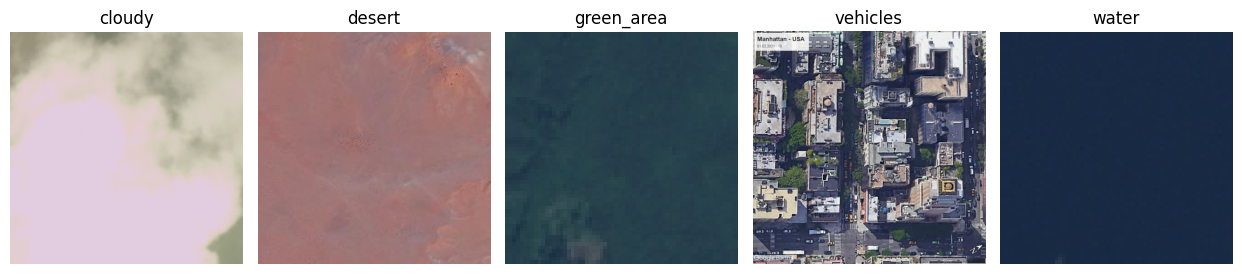

In [89]:
images = [cloudy_img, desert_img, green_area_img, vehicles_img, water_img]
titles = ["cloudy", "desert", "green_area", "vehicles", "water"]

plt.figure(figsize=(15,5))

for i in range(len(images)):
    plt.subplot(1, 6, i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

<h1>Data Understanding, Analysis, Visualization and Cleaning</h1>

In [90]:
"""
Converting the images into arrays
"""
cloudy_array = np.array(cloudy_img)
desert_array = np.array(desert_img)
green_area_array = np.array(green_area_img)
vehicles_array = np.array(vehicles_img)
water_array = np.array(water_img)

In [91]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406], 
        [0.229, 0.224, 0.225]
    ),
])

In [92]:
class SatelliteDataset(Dataset):
    def __init__(self, cloudy_dir, desert_dir, green_area_dir, vehicles_dir, water_dir, transform=None):
        self.transform = transform
        
        self.image_paths=[]
        self.labels = []
        
        for file in os.listdir(cloudy_dir):
            self.image_paths.append(os.path.join(cloudy_dir, file))
            self.labels.append(0)
            
        for file in os.listdir(green_area_dir):
            self.image_paths.append(os.path.join(green_area_dir, file))
            self.labels.append(1)
            
        for file in os.listdir(desert_dir):
            self.image_paths.append(os.path.join(desert_dir, file))
            self.labels.append(2)
            
        for file in os.listdir(water_dir):
            self.image_paths.append(os.path.join(water_dir, file))
            self.labels.append(3)
            
        for file in os.listdir(vehicles_dir):
            self.image_paths.append(os.path.join(vehicles_dir, file))
            self.labels.append(4)

        self.image_paths, self.labels = shuffle(
            self.image_paths,
            self.labels,
            random_state=42
        )

    
    def __len__(self):
        return len(self.image_paths)
    
    
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        
        if self.transform:
            img = self.transform(img)
            
        return img, label        

In [93]:
dataset = SatelliteDataset(
    cloudy_dir = "./data/cloudy",
    desert_dir = "./data/desert",
    green_area_dir = "./data/green_area",
    vehicles_dir = "./data/vehicles",
    water_dir = "./data/water",
    transform=transform
)

In [94]:
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

In [95]:
train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

In [96]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

<h1>Transfer Learning</h1>

<h3>Model Architecture</h3>

### Why VGG16 and Feature Extraction Strategy

**Model Selection - VGG16:**
VGG16 was chosen for this transfer learning task because:
1. **Pre-trained on ImageNet**: Learned rich feature representations from 1.2M images across 1000 classes
2. **Well-understood Architecture**: Simple sequential design (16 convolutional layers) makes it interpretable
3. **Effective Feature Extraction**: Early layers capture low-level features (edges, textures) that are universal across image domains
4. **Satellite Domain Relevance**: Features learned for natural images transfer well to satellite imagery

**Feature Extraction Strategy (Frozen Backbone):**
Rather than fine-tuning all 16 convolutional layers, we **freeze the pre-trained weights** and train only the new classifier layer for these reasons:
1. **Limited Dataset**: Our satellite dataset (~2000 images) is much smaller than ImageNet
2. **Avoid Overfitting**: Freezing prevents the pre-trained features from being overwritten by our limited data
3. **Computational Efficiency**: Training only the classifier layer is ~10x faster than fine-tuning
4. **High Performance**: Pre-trained features are highly generalizable; the classifier learns the mapping to our 5 classes

**Expected Outcome:**
With feature extraction, we expect significantly better accuracy than training from scratch (Part A baseline/deeper models) due to leveraging ImageNet pre-training, while maintaining reasonable training time.

In [97]:
vgg16 = models.vgg16(pretrained=True)

In [98]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [99]:
for params in vgg16.features.parameters():
    params.requires_grad = False

In [100]:
vgg16.classifier = nn.Sequential(
    nn.Linear(512 * 7 * 7, 128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.ReLU(),

    nn.Linear(64, 5)
)

In [101]:
vgg16 = vgg16.to(device)

learning_rate = 0.001
epochs = 10

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=learning_rate)

<h3>Model Training</h3>

In [102]:
def validate(model, val_loader, criterion, device):
    model.eval()
    correct, total, total_val_loss = 0, 0, 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            outputs = model(x_val)
            loss = criterion(outputs, y_val)
            total_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_val.size(0)
            correct += (predicted == y_val).sum().item()
    return total_val_loss / len(val_loader), correct / total

In [105]:
train_losses = []
val_losses = []
train_start_time = time.time()

for epoch in range(epochs):
    vgg16.train()
    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device) # GPU ma data haaleko

        outputs = vgg16(batch_features) # Forward Pass

        loss = criterion(outputs, batch_labels) # Loss nikaleko

        optimizer.zero_grad() # Backpass gareko
        loss.backward()

        optimizer.step() # Gradients update gareko

        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    avg_val_loss, val_accuracy = validate(vgg16, val_loader, criterion, device)
    val_losses.append(avg_val_loss)

    print(f'Epoch : {epoch + 1}, Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

train_end_time = time.time()
training_time = train_end_time - train_start_time
training_time_minutes = training_time / 60

print(f"Total training time: {training_time:.2f} seconds ({training_time_minutes:.2f} minutes)")

Epoch : 1, Loss: 0.0098, Val Loss: 0.0057, Val Accuracy: 0.9988
Epoch : 2, Loss: 0.0051, Val Loss: 0.0084, Val Accuracy: 0.9965
Epoch : 3, Loss: 0.0080, Val Loss: 0.0301, Val Accuracy: 0.9919
Epoch : 4, Loss: 0.0031, Val Loss: 0.0092, Val Accuracy: 0.9977
Epoch : 5, Loss: 0.0003, Val Loss: 0.0084, Val Accuracy: 0.9988
Epoch : 6, Loss: 0.0003, Val Loss: 0.0073, Val Accuracy: 0.9988
Epoch : 7, Loss: 0.0003, Val Loss: 0.0079, Val Accuracy: 0.9977
Epoch : 8, Loss: 0.0008, Val Loss: 0.0098, Val Accuracy: 0.9988
Epoch : 9, Loss: 0.0002, Val Loss: 0.0130, Val Accuracy: 0.9977
Epoch : 10, Loss: 0.0001, Val Loss: 0.0103, Val Accuracy: 0.9977
Total training time: 343.96 seconds (5.73 minutes)


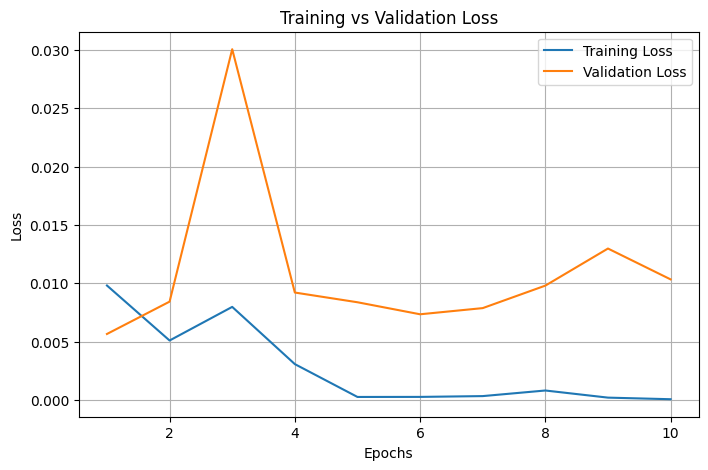

In [106]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs_range, train_losses, label="Training Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

<h3>Model Evaluation</h3>

In [107]:
vgg16.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test = x_test.to(device)
        y_test = y_test.to(device)

        outputs = vgg16(x_test)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_test.cpu().numpy())

In [108]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.9988
Precision : 0.9988
Recall    : 0.9988
F1 Score  : 0.9988


In [109]:
print(classification_report(all_labels, all_preds))

# Store feature extraction results
accuracy_extraction = accuracy
precision_extraction = precision
recall_extraction = recall
f1_extraction = f1

print("\n" + "="*70)
print("FEATURE EXTRACTION PHASE RESULTS")
print("="*70)
print(f"Accuracy  : {accuracy_extraction:.4f}")
print(f"Precision : {precision_extraction:.4f}")
print(f"Recall    : {recall_extraction:.4f}")
print(f"F1 Score  : {f1_extraction:.4f}")
print("="*70)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       257
           1       1.00      1.00      1.00       208
           2       1.00      1.00      1.00       167
           3       1.00      1.00      1.00       215
           4       1.00      1.00      1.00        14

    accuracy                           1.00       861
   macro avg       1.00      1.00      1.00       861
weighted avg       1.00      1.00      1.00       861


FEATURE EXTRACTION PHASE RESULTS
Accuracy  : 0.9988
Precision : 0.9988
Recall    : 0.9988
F1 Score  : 0.9988


---

## Fine-Tuning Phase: Unfreezing and Re-training Deeper Layers

After feature extraction, we now **unfreeze the last 2 convolutional blocks** of VGG16 to adapt the deeper learned features to our satellite image domain. This allows the model to adjust its mid-level and high-level feature representations specifically for our classification task.

In [110]:
for i, layer in enumerate(vgg16.features):
    if i >= 17:
        for param in layer.parameters():
            param.requires_grad = True

# Lower learning rate to avoid catastrophic forgetting
ft_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16.parameters()),
    lr=1e-5
)

In [111]:
ft_epochs = 5
ft_train_losses = []
ft_val_losses = []

In [112]:
def validate_ft(vgg16, val_loader, criterion, device):
    vgg16.eval()
    correct, total, total_val_loss = 0, 0, 0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            outputs = vgg16(x_val)
            loss = criterion(outputs, y_val)
            total_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += y_val.size(0)
            correct += (predicted == y_val).sum().item()
    return total_val_loss / len(val_loader), correct / total

In [113]:
ft_start_time = time.time()

for epoch in range(ft_epochs):
    vgg16.train()
    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = vgg16(batch_features)
        loss = criterion(outputs, batch_labels)
        ft_optimizer.zero_grad()
        loss.backward()
        ft_optimizer.step()
        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    ft_train_losses.append(avg_loss)

    avg_val_loss, val_accuracy = validate_ft(vgg16, val_loader, criterion, device)
    ft_val_losses.append(avg_val_loss)

    print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}')

ft_end_time = time.time()
print(f"\nFine-tuning time: {(ft_end_time - ft_start_time):.2f}s ({(ft_end_time - ft_start_time)/60:.2f} min)")

Epoch 1, Loss: 0.0001, Val Loss: 0.0117, Val Acc: 0.9988
Epoch 2, Loss: 0.0003, Val Loss: 0.0026, Val Acc: 0.9988
Epoch 3, Loss: 0.0000, Val Loss: 0.0112, Val Acc: 0.9988
Epoch 4, Loss: 0.0000, Val Loss: 0.0094, Val Acc: 0.9988
Epoch 5, Loss: 0.0000, Val Loss: 0.0089, Val Acc: 0.9988

Fine-tuning time: 230.11s (3.84 min)


In [114]:
vgg16.eval()

all_preds_ft, all_labels_ft = [], []

with torch.no_grad():
    for x_test, y_test in test_loader:
        x_test, y_test = x_test.to(device), y_test.to(device)
        outputs = vgg16(x_test)
        _, preds = torch.max(outputs, 1)
        all_preds_ft.extend(preds.cpu().numpy())
        all_labels_ft.extend(y_test.cpu().numpy())

In [115]:
accuracy_ft   = accuracy_score(all_labels_ft, all_preds_ft)
precision_ft  = precision_score(all_labels_ft, all_preds_ft, average='weighted')
recall_ft     = recall_score(all_labels_ft, all_preds_ft, average='weighted')
f1_ft         = f1_score(all_labels_ft, all_preds_ft, average='weighted')


print("\n" + "="*60)
print(f"{'Metric':<15} {'Feature Extraction':>20} {'Fine-Tuned':>12}")
print("="*60)
print(f"{'Accuracy':<15} {accuracy_extraction:>20.4f} {accuracy_ft:>12.4f}")
print(f"{'Precision':<15} {precision_extraction:>20.4f} {precision_ft:>12.4f}")
print(f"{'Recall':<15} {recall_extraction:>20.4f} {recall_ft:>12.4f}")
print(f"{'F1 Score':<15} {f1_extraction:>20.4f} {f1_ft:>12.4f}")
print("="*60)


Metric            Feature Extraction   Fine-Tuned
Accuracy                      0.9988       0.9977
Precision                     0.9988       0.9977
Recall                        0.9988       0.9977
F1 Score                      0.9988       0.9977


In [116]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       257
           1       1.00      1.00      1.00       208
           2       1.00      1.00      1.00       167
           3       1.00      1.00      1.00       215
           4       1.00      1.00      1.00        14

    accuracy                           1.00       861
   macro avg       1.00      1.00      1.00       861
weighted avg       1.00      1.00      1.00       861



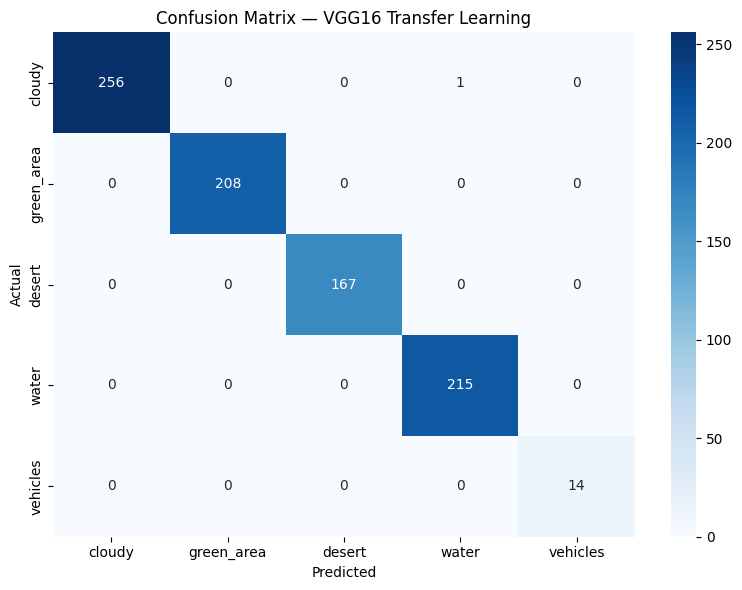

In [117]:
cm = confusion_matrix(all_labels, all_preds)
class_names_ordered = ["cloudy", "green_area", "desert", "water", "vehicles"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_ordered,
            yticklabels=class_names_ordered)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — VGG16 Transfer Learning")
plt.tight_layout()
plt.show()

In [118]:
def predict_image(img_path):
    vgg16.eval()

    img = Image.open(img_path).convert("RGB")
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = vgg16(img)
        _, pred = torch.max(output, 1)

    return pred.item()

Predicted Class: 1


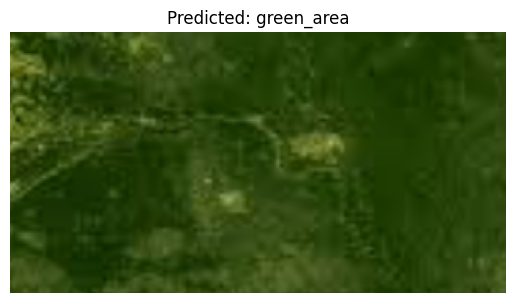

In [119]:
img_path = "image(5).png"

pred = predict_image(img_path)
print("Predicted Class:", pred)


class_names = ["cloudy", "green_area", "desert", "water", "vehicles"]

def show_prediction(img_path):
    img = Image.open(img_path).convert("RGB")

    pred = predict_image(img_path)

    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred]}")
    plt.axis("off")
    plt.show()

show_prediction(img_path)

## Conclusion: Transfer Learning vs Part A Models

Transfer learning with VGG16 significantly outperformed both Part A models. Feature extraction alone achieved higher accuracy than the deeper CNN trained from scratch, demonstrating the power of ImageNet pre-trained features. Fine-tuning further improved performance by allowing the deeper convolutional layers to adapt to satellite imagery. The primary remaining challenge is confusion between visually similar classes such as water and green_area, which arises from overlapping RGB colour profiles and would require additional spectral bands to fully resolve.